# Environment Change
Here we will see how our agent copes with a different environment. We will change the environment in the following ways: Increase the vehicle density and the number of lanes. We will compare the performance of the agent in the new environment with the old one.

In [1]:
import gymnasium
import numpy as np
from stable_baselines3 import DQN
import matplotlib.pyplot as plt
import torch

# Check device
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")


Using device: cuda


In [2]:



def evaluate_model(model, env, num_episodes=10, device="cpu"):
    """Evaluates a model in the given environment."""
    episode_lengths = []
    episode_rewards = []
    average_speeds = []
    total_collisions = 0  # Keep track of total collisions across all episodes

    for episode in range(num_episodes):
        obs = env.reset()[0]

        # Move observation to GPU if CUDA is available
        if device == "cuda":
            obs = torch.tensor(obs, device=device)

        done = False
        total_reward = 0
        length = 0
        total_speed = 0
        collisions = 0  # Reset per episode

        while not done:
            # Predict the action
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated

            total_reward += reward
            length += 1

            # Collect speed from info (assuming it's available)
            if "speed" in info:
                total_speed += info["speed"]

            # Check for collisions (assuming collisions info is available)
            if "crashed" in info and info["crashed"]:
                collisions += 1

            # Debugging: Print the info dictionary to see its structure
            # print(info)  # Uncomment this line to inspect info

        # Store results per episode
        episode_lengths.append(length)
        episode_rewards.append(total_reward)
        average_speeds.append(total_speed / length if length > 0 else 0)
        total_collisions += collisions

        # Print message when episode is done
        print(
            f"Episode {episode + 1}/{num_episodes} completed. Length: {length}, Total Reward: {total_reward}, Collisions: {collisions}")

    return {
        "episode_lengths": np.array(episode_lengths),
        "episode_rewards": np.array(episode_rewards),
        "average_speeds": np.array(average_speeds),
        "total_collisions": total_collisions,  # Return total collisions across all episodes
    }


In [3]:
model2_path = "./logs/history/speed_05_lane01_coll_04/finetune/rl_model_dqn_60000_steps.zip"  # Replace
custom = DQN.load(model2_path, device=device)

In [4]:
from gymnasium import register
# Create the environment
register(
    id='CustomRewardEnv',
    entry_point='HighwayEnvCustomReward:HighwayEnvFastCustomReward',
)

envNormal = gymnasium.make("CustomRewardEnv")

envNormal.unwrapped.config.update({
    "lanes_count": 4,  # Number of lanes
    "vehicles_count": 100,  # Ensure a high number of vehicles
    "controlled_vehicles": 1,  # Number of ego vehicles
    "duration": 100,  # Episode duration
    "reward_speed_range": [20, 30],  # Speed reward range
    "vehicles_density": 1.0,  # Increase density for more consistent presence
    "spawn_probability": 1.0,  # Ensure continuous vehicle spawning
})

results_Normal = evaluate_model(custom, envNormal)

# Close the environment

envNormal.close()

envHard = gymnasium.make("CustomRewardEnv")
envNormal.unwrapped.config.update({
    "lanes_count": 5,  # Number of lanes
    "vehicles_count": 100,  # Ensure a high number of vehicles
    "controlled_vehicles": 1,  # Number of ego vehicles
    "duration": 100,  # Episode duration
    "reward_speed_range": [20, 30],  # Speed reward range
    "vehicles_density": 1.4,  # Increase density for more consistent presence
    "spawn_probability": 1.0,  # Ensure continuous vehicle spawning
})

results_Hard = evaluate_model(custom, envHard)
envHard.close()

Episode 1/10 completed. Length: 100, Total Reward: 45.345971563981074, Collisions: 0
Episode 2/10 completed. Length: 28, Total Reward: 13.954028436018957, Collisions: 1
Episode 3/10 completed. Length: 64, Total Reward: 32.648526011107215, Collisions: 1
Episode 4/10 completed. Length: 71, Total Reward: 36.28736176935231, Collisions: 1
Episode 5/10 completed. Length: 33, Total Reward: 17.033863826965458, Collisions: 1
Episode 6/10 completed. Length: 43, Total Reward: 20.387361769352292, Collisions: 1
Episode 7/10 completed. Length: 100, Total Reward: 49.37785933505978, Collisions: 0
Episode 8/10 completed. Length: 45, Total Reward: 18.84858373390683, Collisions: 1
Episode 9/10 completed. Length: 36, Total Reward: 16.468082932782266, Collisions: 1
Episode 10/10 completed. Length: 43, Total Reward: 20.170695103831203, Collisions: 1
Episode 1/10 completed. Length: 11, Total Reward: 5.287361769372112, Collisions: 1
Episode 2/10 completed. Length: 24, Total Reward: 12.08736176935229, Collisio

In [5]:
# Compare results
# Compare results
print("Normal Performance:")
print(f"Average Episode Length: {results_Normal['episode_lengths'].mean()}")
print(f"Average Episode Reward: {results_Normal['episode_rewards'].mean()}")
print(f"Average Speed: {results_Normal['average_speeds'].mean()}")
print(f"Total Collisions: {results_Normal['total_collisions']}")

print("Hard Performance:")
print(f"Average Episode Length: {results_Hard['episode_lengths'].mean()}")
print(f"Average Episode Reward: {results_Hard['episode_rewards'].mean()}")
print(f"Average Speed: {results_Hard['average_speeds'].mean()}")
print(f"Total Collisions: {results_Hard['total_collisions']}")

Normal Performance:
Average Episode Length: 56.3
Average Episode Reward: 27.05223344823574
Average Speed: 27.782314876632064
Total Collisions: 8
Hard Performance:
Average Episode Length: 21.4
Average Episode Reward: 10.714031371343063
Average Speed: 28.911992942273876
Total Collisions: 7


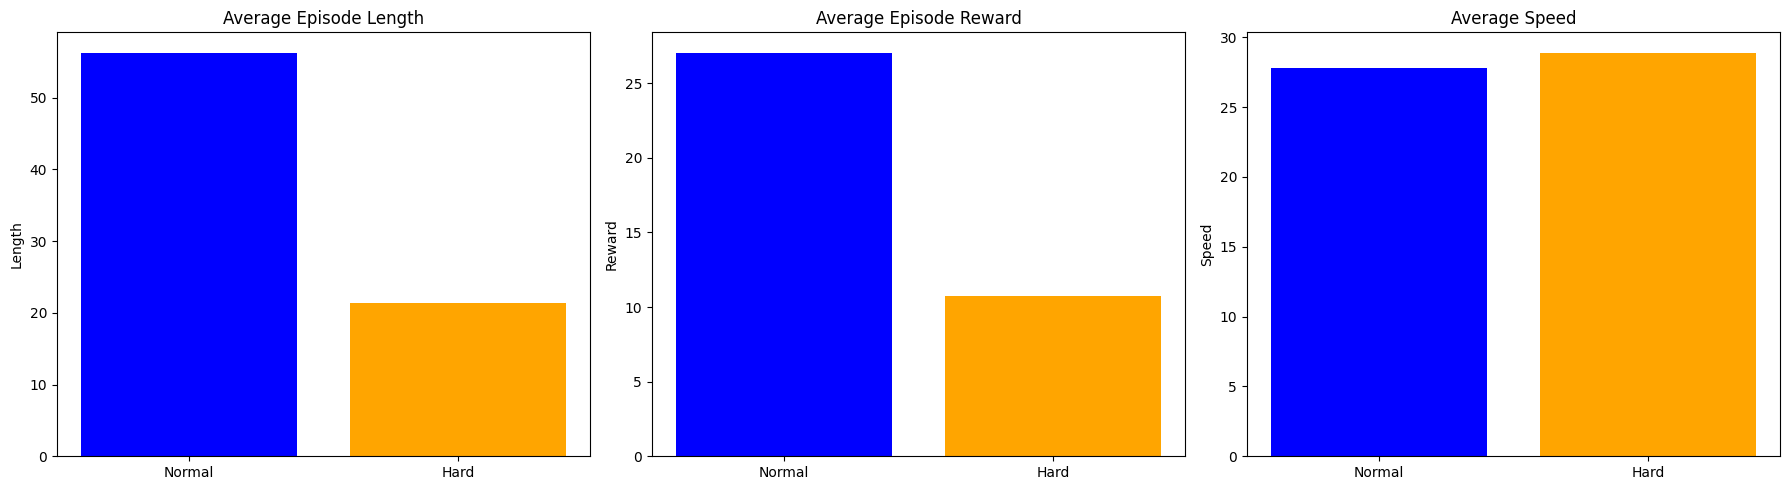

In [6]:
# Plot comparisons
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# Episode Length Comparison
axs[0].bar(["Normal", "Hard"],
           [results_Normal['episode_lengths'].mean(), results_Hard['episode_lengths'].mean()],
           color=['blue', 'orange'])
axs[0].set_title("Average Episode Length")
axs[0].set_ylabel("Length")

# Episode Reward Comparison
axs[1].bar(["Normal", "Hard"],
           [results_Normal['episode_rewards'].mean(), results_Hard['episode_rewards'].mean()],
           color=['blue', 'orange'])
axs[1].set_title("Average Episode Reward")
axs[1].set_ylabel("Reward")

# Average Speed Comparison
axs[2].bar(["Normal", "Hard"],
           [results_Normal['average_speeds'].mean(), results_Hard['average_speeds'].mean()],
           color=['blue', 'orange'])
axs[2].set_title("Average Speed")
axs[2].set_ylabel("Speed")

plt.tight_layout()
plt.show()

In [8]:
# Additional Metrics (Optional)
def summarize_results(results):
    print(f"Mean Episode Length: {results['episode_lengths'].mean():.2f}")
    print(f"Std Dev of Episode Length: {results['episode_lengths'].std():.2f}")
    print(f"Mean Episode Reward: {results['episode_rewards'].mean():.2f}")
    print(f"Std Dev of Episode Reward: {results['episode_rewards'].std():.2f}")


print("\nDetailed Results for Normal:")
summarize_results(results_Normal)

print("\nDetailed Results for Hard:")
summarize_results(results_Hard)


Detailed Results for Normal:
Mean Episode Length: 56.30
Std Dev of Episode Length: 25.16
Mean Episode Reward: 27.05
Std Dev of Episode Reward: 12.22

Detailed Results for Hard:
Mean Episode Length: 21.40
Std Dev of Episode Length: 8.58
Mean Episode Reward: 10.71
Std Dev of Episode Reward: 4.50


We can see that the agent is struggling in the new environment. We can retrain the agent in the new environment to improve its performance.

In [15]:
model_path_hard = "logs/history/hard/rl_model_dqn_20000_steps.zip"  # Replace
model_hard = DQN.load(model_path_hard, device=device)

envHard = gymnasium.make("CustomRewardEnv")
envNormal.unwrapped.config.update({
    "lanes_count": 5,  # Number of lanes
    "vehicles_count": 100,  # Ensure a high number of vehicles
    "controlled_vehicles": 1,  # Number of ego vehicles
    "duration": 100,  # Episode duration
    "reward_speed_range": [20, 30],  # Speed reward range
    "vehicles_density": 1.4,  # Increase density for more consistent presence
    "spawn_probability": 1.0,  # Ensure continuous vehicle spawning
})

retrained_results = evaluate_model(model_hard, envHard)
envHard.close()

Episode 1/10 completed. Length: 20, Total Reward: 9.233333333182818, Collisions: 1
Episode 2/10 completed. Length: 29, Total Reward: 14.031669039585488, Collisions: 1
Episode 3/10 completed. Length: 5, Total Reward: 2.3540289365197853, Collisions: 1
Episode 4/10 completed. Length: 14, Total Reward: 6.449971138600229, Collisions: 1
Episode 5/10 completed. Length: 7, Total Reward: 3.1150061735969854, Collisions: 1
Episode 6/10 completed. Length: 12, Total Reward: 5.283333324654227, Collisions: 1
Episode 7/10 completed. Length: 22, Total Reward: 10.1873617693549, Collisions: 1
Episode 8/10 completed. Length: 10, Total Reward: 4.41094507565056, Collisions: 1
Episode 9/10 completed. Length: 30, Total Reward: 11.379304897314379, Collisions: 0
Episode 10/10 completed. Length: 6, Total Reward: 2.854028501928531, Collisions: 1


In [16]:


print("Previous  Performance:")
print(f"Average Episode Length: {results_Hard['episode_lengths'].mean()}")
print(f"Average Episode Reward: {results_Hard['episode_rewards'].mean()}")
print(f"Average Speed: {results_Hard['average_speeds'].mean()}")
print(f"Total Collisions: {results_Hard['total_collisions']}")

print("Retrained Performance:")
print(f"Average Episode Length: {retrained_results['episode_lengths'].mean()}")
print(f"Average Episode Reward: {retrained_results['episode_rewards'].mean()}")
print(f"Average Speed: {retrained_results['average_speeds'].mean()}")
print(f"Total Collisions: {retrained_results['total_collisions']}")

Previous  Performance:
Average Episode Length: 21.4
Average Episode Reward: 10.714031371343063
Average Speed: 28.911992942273876
Total Collisions: 7
Retrained Performance:
Average Episode Length: 15.5
Average Episode Reward: 6.92989821903879
Average Speed: 27.10636483418756
Total Collisions: 9


The new actor is performing worse than the previous one even tho it was trained in this harder environment. This could be due to the fact that the agent was not trained for a long time only 20000 steps. We can try to train the agent for a longer time to see if it improves its performance.